# Gemma-4: ToxiGen Grouped PA-CCS

This notebook evaluates Gemma-4 on ToxiGen with grouped analysis by `target_group`.

Buckets:
1. `women`
2. `lgbtq+`
3. `race`
4. `disabilities`

Workflow:
1. Load grouped ToxiGen paired data
2. Map `target_group` into the 4 canonical buckets
3. Run PA-CCS separately per bucket
4. Use stratified train/test splits within each bucket
5. Compare layer-wise metrics across buckets and save artifacts

In [1]:
REPO_URL = "https://github.com/vvv-hikka/latent-alignment-project.git"
!rm -rf /content/latent-alignment-project
!git clone {REPO_URL} /content/latent-alignment-project
!ls -la /content/latent-alignment-project
!ls -la /content/latent-alignment-project/latent_alignment

Cloning into '/content/latent-alignment-project'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (214/214), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 214 (delta 87), reused 148 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (214/214), 5.89 MiB | 17.23 MiB/s, done.
Resolving deltas: 100% (87/87), done.
total 60
drwxr-xr-x  9 root root 4096 Jun 28 08:25 .
drwxr-xr-x  1 root root 4096 Jun 28 08:25 ..
drwxr-xr-x  2 root root 4096 Jun 28 08:25 configs
drwxr-xr-x  3 root root 4096 Jun 28 08:25 data
drwxr-xr-x  8 root root 4096 Jun 28 08:25 .git
drwxr-xr-x  2 root root 4096 Jun 28 08:25 latent_alignment
drwxr-xr-x  2 root root 4096 Jun 28 08:25 notebooks
-rw-r--r--  1 root root  937 Jun 28 08:25 pyproject.toml
-rw-r--r--  1 root root 8326 Jun 28 08:25 README.md
-rw-r--r--  1 root root   32 Jun 28 08:25 requirements-dev.txt
-rw-r--r--  1 root root  253 Jun 28 08:25 requirements.txt
drwxr-xr-x 12 root root 4096 Jun 28 08:25 runs

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/latent-alignment-project")
sys.path.insert(0, str(PROJECT_ROOT))
from latent_alignment.data import load_dataset
from latent_alignment.extract import load_embeddings, load_hf_model, extract_texts, save_embeddings
from latent_alignment.ccs import ProbeConfig, train_ccs_layers, summarize_results
print("Project root:", PROJECT_ROOT)
print("Import OK")

Project root: /content/latent-alignment-project
Import OK


In [3]:
PROJECT_ROOT = Path("/content/latent-alignment-project")

In [4]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from latent_alignment.data import load_dataset
from latent_alignment.extract import load_embeddings, load_hf_model, extract_texts, save_embeddings
from latent_alignment.ccs import ProbeConfig, train_ccs_layers, summarize_results

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/latent-alignment-project


In [5]:
# ---- Experiment config ----
MODEL_NAME = "google/gemma-4-e2b"
MODEL_KIND = "decoder"
STRATEGY = "last-token"
DTYPE = "bfloat16"
MAX_LENGTH = 512
DEVICE = None
TRUST_REMOTE_CODE = False

NORMALIZING = "l2,median"
TEST_SIZE = 0.15
RANDOM_STATE = 71

TOXIGEN_PAIRED_DATASET = PROJECT_ROOT / "data" / "polarity_probing" / "raw" / "toxigen_annotated_test_paired.csv"
RUNS_ROOT = PROJECT_ROOT / "runs"
GROUP_RUNS_ROOT = RUNS_ROOT / "gemma4_e2b_toxigen_groups"
GROUP_DATASETS_ROOT = GROUP_RUNS_ROOT / "_group_datasets"

PROBE_CONFIG = ProbeConfig(
    nepochs=1500,
    ntries=10,
    lr=0.015,
    batch_size=-1,
    weight_decay=0.01,
    lambda_classification=0.0,
    normalizing=NORMALIZING,
    seed=0,
)

CANONICAL_GROUP_MAP = {
    "women": "women",
    "lgbtq+ folks": "lgbtq+",
    "folks with physical disabilities": "disabilities",
    "folks with mental disabilities": "disabilities",
    "asian folks": "race",
    "black folks / african-americans": "race",
    "black/african-american folks": "race",
    "chinese folks": "race",
    "jewish folks": "race",
    "latino/hispanic folks": "race",
    "mexican folks": "race",
    "middle eastern folks": "race",
    "muslim folks": "race",
    "native american/indigenous folks": "race",
}

GROUP_ORDER = ["women", "lgbtq+", "race", "disabilities"]

print(f"Paired dataset: {TOXIGEN_PAIRED_DATASET}")
print(f"Group runs root: {GROUP_RUNS_ROOT}")

Paired dataset: /content/latent-alignment-project/data/polarity_probing/raw/toxigen_annotated_test_paired.csv
Group runs root: /content/latent-alignment-project/runs/gemma4_e2b_toxigen_groups


In [6]:
# Optional: authenticate to Hugging Face if needed for gated Gemma access.
# from huggingface_hub import login
# login(token="YOUR_HF_TOKEN")

model, tokenizer, device = load_hf_model(
    MODEL_NAME,
    model_kind=MODEL_KIND,
    device=DEVICE,
    dtype=DTYPE,
    trust_remote_code=TRUST_REMOTE_CODE,
)
print(f"Model loaded on: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Model loaded on: cuda
CUDA available: True


In [7]:
def ensure_embeddings(
    *,
    dataset_path: Path,
    dataset_format: str,
    embeddings_path: Path,
    model,
    tokenizer,
    device,
):
    dataset = load_dataset(dataset_path, dataset_format=dataset_format)

    if embeddings_path.exists():
        positive, negative = load_embeddings(embeddings_path)
        return dataset, positive, negative

    positive = extract_texts(
        dataset.positive_texts,
        model,
        tokenizer,
        get_all_layers=True,
        strategy=STRATEGY,
        model_kind=MODEL_KIND,
        device=device,
        max_length=MAX_LENGTH,
    )
    negative = extract_texts(
        dataset.negative_texts,
        model,
        tokenizer,
        get_all_layers=True,
        strategy=STRATEGY,
        model_kind=MODEL_KIND,
        device=device,
        max_length=MAX_LENGTH,
    )

    if positive.ndim == 2:
        positive = positive[:, None, :]
        negative = negative[:, None, :]

    embeddings_path.parent.mkdir(parents=True, exist_ok=True)
    save_embeddings(embeddings_path, positive, negative)
    return dataset, positive, negative


def run_pa_ccs(
    *,
    output_dir: Path,
    dataset_path: Path,
    dataset_format: str,
    model,
    tokenizer,
    device,
    probe_config: ProbeConfig = PROBE_CONFIG,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    embeddings_path = output_dir / "embeddings.npz"
    dataset, positive, negative = ensure_embeddings(
        dataset_path=dataset_path,
        dataset_format=dataset_format,
        embeddings_path=embeddings_path,
        model=model,
        tokenizer=tokenizer,
        device=device,
    )

    train_idx, test_idx = dataset.train_test_indices(
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=True,
    )

    train_labels = dataset.labels.iloc[train_idx]
    test_labels = dataset.labels.iloc[test_idx]

    results = train_ccs_layers(
        positive,
        negative,
        dataset.labels,
        train_idx,
        test_idx,
        config=probe_config,
        opposite_indices=dataset.opposite_indices,
        device=device,
    )

    summary_df = pd.DataFrame(summarize_results(results))
    summary_df.to_csv(output_dir / "ccs_summary.csv", index=False)

    full_results = {
        f"layer_{layer}_{key}": value
        for layer, row in results.items()
        for key, value in row.items()
    }
    np.savez_compressed(output_dir / "ccs_full_results.npz", **full_results)

    metadata = {
        "dataset_path": str(dataset_path),
        "dataset_format": dataset_format,
        "train_idx": train_idx.tolist(),
        "test_idx": test_idx.tolist(),
        "probe_config": probe_config.__dict__,
        "split": {
            "test_size": TEST_SIZE,
            "random_state": RANDOM_STATE,
            "stratified": True,
            "train_label_counts": train_labels.value_counts().to_dict(),
            "test_label_counts": test_labels.value_counts().to_dict(),
        },
    }
    (output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    return summary_df.sort_values("accuracy", ascending=False).reset_index(drop=True), metadata

In [8]:
def map_target_group_to_bucket(value: str) -> str | None:
    if pd.isna(value):
        return None
    key = str(value).strip().lower()
    return CANONICAL_GROUP_MAP.get(key)

paired_df = pd.read_csv(TOXIGEN_PAIRED_DATASET)
paired_df["target_group_norm"] = paired_df["target_group"].astype(str).str.strip().str.lower()
paired_df["group_bucket"] = paired_df["target_group_norm"].map(CANONICAL_GROUP_MAP)

unmapped = sorted(paired_df.loc[paired_df["group_bucket"].isna(), "target_group_norm"].unique())
if unmapped:
    print("Unmapped target_group values:")
    for value in unmapped:
        print(" -", value)
    raise ValueError("Found unmapped target_group values. Update CANONICAL_GROUP_MAP.")

bucket_counts = (
    paired_df.groupby("group_bucket", dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("group_bucket")
)
print("Rows per bucket:")
display(bucket_counts)

label_counts = (
    paired_df.groupby(["group_bucket", "is_harmfull_opposition"])
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(["group_bucket", "is_harmfull_opposition"])
)
print("Source label counts per bucket (paired CSV label):")
display(label_counts)

present_groups = sorted(paired_df["target_group_norm"].unique())
print("Mapped target_group values:")
for g in present_groups:
    print(f" - {g} -> {CANONICAL_GROUP_MAP[g]}")

Rows per bucket:


,group_bucket,rows
0,disabilities,72
1,lgbtq+,30
2,race,262
3,women,38


Source label counts per bucket (paired CSV label):


,group_bucket,is_harmfull_opposition,rows
0,disabilities,1,72
1,lgbtq+,1,30
2,race,1,262
3,women,1,38


Mapped target_group values:
 - asian folks -> race
 - black folks / african-americans -> race
 - black/african-american folks -> race
 - chinese folks -> race
 - folks with mental disabilities -> disabilities
 - folks with physical disabilities -> disabilities
 - jewish folks -> race
 - latino/hispanic folks -> race
 - lgbtq+ folks -> lgbtq+
 - mexican folks -> race
 - middle eastern folks -> race
 - muslim folks -> race
 - native american/indigenous folks -> race
 - women -> women


In [9]:
GROUP_RUNS_ROOT.mkdir(parents=True, exist_ok=True)
GROUP_DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

summaries_by_group: dict[str, pd.DataFrame] = {}
run_metadata_by_group: dict[str, dict] = {}
source_stats = []

for bucket in GROUP_ORDER:
    bucket_df = paired_df.loc[paired_df["group_bucket"] == bucket].copy()
    if bucket_df.empty:
        print(f"Skipping {bucket}: no rows")
        continue

    source_stats.append(
        {
            "bucket": bucket,
            "source_rows": len(bucket_df),
            "source_positive_labels": int(bucket_df["is_harmfull_opposition"].sum()),
        }
    )

    # Keep only columns expected by paired loader.
    dataset_cols = [
        "positive_text",
        "negative_text",
        "is_harmfull_opposition",
        "target_group",
        "toxic_text",
        "benign_rewrite",
    ]
    bucket_dataset_path = GROUP_DATASETS_ROOT / f"toxigen_{bucket}.csv"
    bucket_df[dataset_cols].to_csv(bucket_dataset_path, index=False)

    output_dir = GROUP_RUNS_ROOT / bucket
    print(f"Running bucket={bucket} | rows={len(bucket_df)}")

    summary_df, metadata = run_pa_ccs(
        output_dir=output_dir,
        dataset_path=bucket_dataset_path,
        dataset_format="paired",
        model=model,
        tokenizer=tokenizer,
        device=device,
    )

    metadata["bucket"] = bucket
    metadata["source_rows"] = len(bucket_df)
    metadata["source_target_groups"] = sorted(bucket_df["target_group_norm"].unique().tolist())
    (output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    summaries_by_group[bucket] = summary_df
    run_metadata_by_group[bucket] = metadata

    display(summary_df.head(10))

source_stats_df = pd.DataFrame(source_stats)
print("Source rows per bucket:")
display(source_stats_df)
print(f"Saved grouped runs under: {GROUP_RUNS_ROOT}")

Running bucket=women | rows=38


Training CCS: 100%|██████████| 36/36 [17:05<00:00, 28.49s/it]


,layer,accuracy,silhouette,polar_consistency_mean,contradiction_index_mean,bias
0,2,0.750000,0.100111,4.068823e-01,0.660595,-0.242557
1,1,0.666667,0.419312,2.492315e-01,0.499233,-0.166433
2,18,0.666667,0.270002,1.538023e-32,0.666667,-0.108673
3,3,0.666667,0.240707,1.516802e-01,0.832715,-0.173762
4,13,0.666667,0.127873,8.333331e-02,0.666667,-0.216596
5,7,0.666667,0.172792,0.000000e+00,0.833333,-0.294243
6,11,0.666667,0.196801,0.000000e+00,0.833333,0.120680
7,8,0.666667,0.083386,3.179973e-33,0.833333,-0.235074
8,35,0.583333,0.247579,0.000000e+00,0.666667,-0.284409
9,15,0.583333,0.222202,0.000000e+00,0.894755,-0.132019


Running bucket=lgbtq+ | rows=30


Training CCS: 100%|██████████| 36/36 [16:47<00:00, 27.99s/it]


...

Training CCS: 100%|██████████| 36/36 [16:59<00:00, 28.32s/it]


,layer,accuracy,silhouette,polar_consistency_mean,contradiction_index_mean,bias
0,3,0.681818,0.295272,5.813531e-15,0.727273,-0.265826
1,1,0.681818,0.442913,3.905603e-01,0.637065,-0.269672
2,2,0.681818,0.238306,2.045883e-01,0.608142,-0.225128
3,4,0.681818,0.246390,4.545455e-02,0.636364,-0.146089
4,6,0.681818,0.226674,4.545455e-02,0.545455,-0.302772
5,5,0.681818,0.228251,1.965997e-01,0.779114,-0.211675
6,9,0.636364,0.087341,2.212661e-01,0.813680,-0.187232
7,29,0.590909,0.418978,3.084500e-26,0.818182,-0.167564
8,7,0.590909,0.127365,5.081973e-02,0.758511,-0.333657
9,12,0.590909,0.456706,0.000000e+00,1.088436,-0.398319


Source rows per bucket:


,bucket,source_rows,source_positive_labels
0,women,38,38
1,lgbtq+,30,30
2,race,262,262
3,disabilities,72,72


Saved grouped runs under: /content/latent-alignment-project/runs/gemma4_e2b_toxigen_groups


,bucket,n_layers,best_layer,best_acc,mean_acc,best_silhouette,max_silhouette,polar_consistency_abs_at_best,mean_polar_consistency_abs,contradiction_at_best,mean_contradiction
0,lgbtq+,36,8,0.777778,0.620370,0.202086,0.512836,1.235808e-01,0.067017,0.751451,0.850392
1,women,36,2,0.750000,0.590278,0.100111,0.419312,4.068823e-01,0.058042,0.660595,0.716955
2,disabilities,36,3,0.681818,0.579545,0.295272,0.466439,5.813531e-15,0.047714,0.727273,0.785660
3,race,36,31,0.620253,0.558720,0.274131,0.468575,4.678185e-02,0.050811,0.666667,0.728818


Saved grouped metrics summary: /content/latent-alignment-project/runs/gemma4_e2b_toxigen_groups/group_metrics_summary.csv


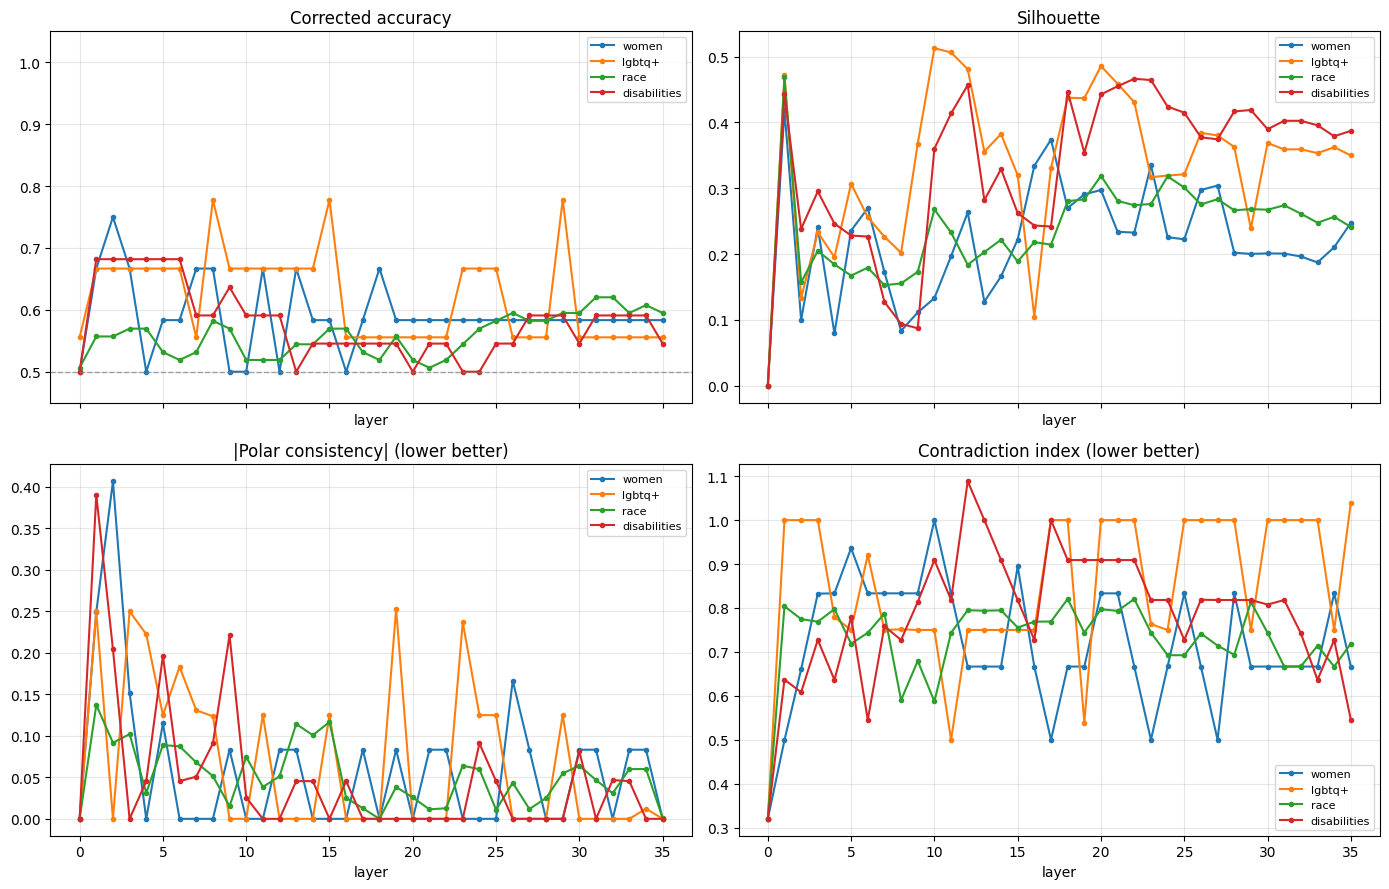

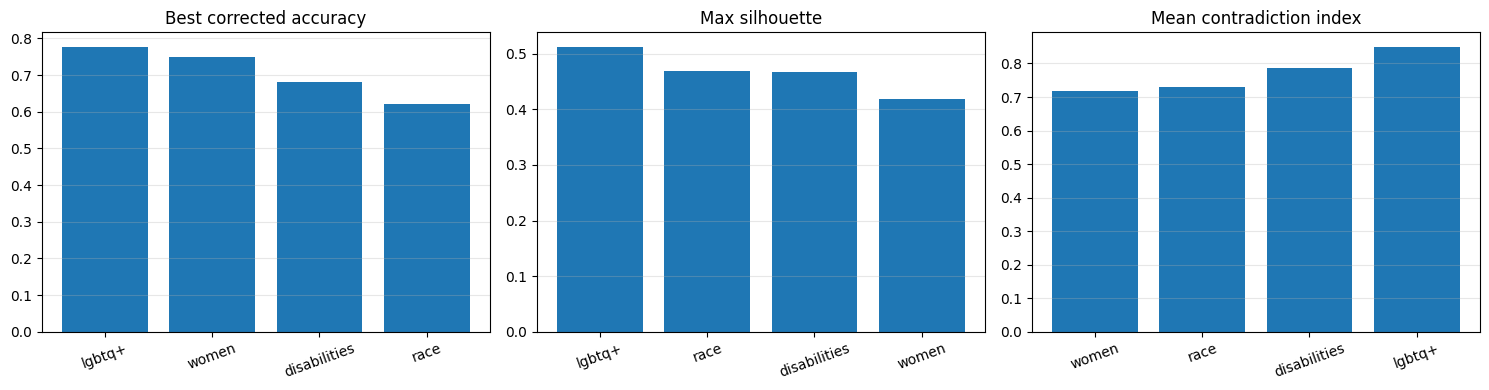

In [10]:
if not summaries_by_group:
    raise RuntimeError("No grouped summaries found. Run the grouped PA-CCS cell first.")


def prepare_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values("layer").reset_index(drop=True).copy()
    out["acc_corrected"] = np.maximum(out["accuracy"], 1 - out["accuracy"])
    out["polar_consistency_abs"] = out["polar_consistency_mean"].abs()
    return out

def summarize_bucket(bucket: str, df: pd.DataFrame) -> dict:
    m = prepare_metrics(df)
    best = m.loc[m["acc_corrected"].idxmax()]
    return {
        "bucket": bucket,
        "n_layers": len(m),
        "best_layer": int(best["layer"]),
        "best_acc": float(best["acc_corrected"]),
        "mean_acc": float(m["acc_corrected"].mean()),
        "best_silhouette": float(best["silhouette"]),
        "max_silhouette": float(m["silhouette"].max()),
        "polar_consistency_abs_at_best": float(abs(best["polar_consistency_mean"])),
        "mean_polar_consistency_abs": float(m["polar_consistency_abs"].mean()),
        "contradiction_at_best": float(best["contradiction_index_mean"]),
        "mean_contradiction": float(m["contradiction_index_mean"].mean()),
    }

prepared = {bucket: prepare_metrics(df) for bucket, df in summaries_by_group.items()}
bucket_report = pd.DataFrame([summarize_bucket(bucket, df) for bucket, df in prepared.items()])
bucket_report = bucket_report.sort_values("best_acc", ascending=False).reset_index(drop=True)

display(bucket_report)

analysis_csv = GROUP_RUNS_ROOT / "group_metrics_summary.csv"
bucket_report.to_csv(analysis_csv, index=False)
print(f"Saved grouped metrics summary: {analysis_csv}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
metric_panels = [
    ("acc_corrected", "Corrected accuracy", (0.45, 1.05)),
    ("silhouette", "Silhouette", (None, None)),
    ("polar_consistency_abs", "|Polar consistency| (lower better)", (None, None)),
    ("contradiction_index_mean", "Contradiction index (lower better)", (None, None)),
]

for ax, (col, title, ylim) in zip(axes.ravel(), metric_panels):
    for bucket in GROUP_ORDER:
        if bucket not in prepared:
            continue
        df = prepared[bucket]
        ax.plot(df["layer"], df[col], marker="o", linewidth=1.5, markersize=3, label=bucket)
    if col == "acc_corrected":
        ax.axhline(0.5, linestyle="--", color="gray", linewidth=1, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("layer")
    if ylim[0] is not None or ylim[1] is not None:
        ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_metrics = [
    ("best_acc", "Best corrected accuracy"),
    ("max_silhouette", "Max silhouette"),
    ("mean_contradiction", "Mean contradiction index"),
]
for ax, (col, title) in zip(axes, bar_metrics):
    plot_df = bucket_report.sort_values(col, ascending=(col == "mean_contradiction"))
    ax.bar(plot_df["bucket"], plot_df[col])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
expected_files = ["ccs_summary.csv", "ccs_full_results.npz", "metadata.json"]
validation_rows = []

for bucket in GROUP_ORDER:
    run_dir = GROUP_RUNS_ROOT / bucket
    if not run_dir.exists():
        validation_rows.append({"bucket": bucket, "exists": False, "missing_files": ",".join(expected_files)})
        continue
    missing = [name for name in expected_files if not (run_dir / name).exists()]
    validation_rows.append(
        {
            "bucket": bucket,
            "exists": True,
            "missing_files": ",".join(missing),
            "summary_rows": (
                pd.read_csv(run_dir / "ccs_summary.csv").shape[0]
                if (run_dir / "ccs_summary.csv").exists()
                else 0
            ),
        }
    )

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

if (validation_df["exists"] == False).any() or validation_df["missing_files"].astype(bool).any():
    print("Validation warnings detected. Inspect missing files before exporting.")
else:
    print("All group run folders validated.")

,bucket,exists,missing_files,summary_rows
0,women,True,,36
1,lgbtq+,True,,36
2,race,True,,36
3,disabilities,True,,36


All group run folders validated.


In [12]:
# Optional export helper for Colab.
# Creates one zip containing all grouped run artifacts.
from pathlib import Path
import shutil

zip_path = PROJECT_ROOT / "runs" / "gemma4_e2b_toxigen_groups.zip"
shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", GROUP_RUNS_ROOT)
print(f"Created: {zip_path}")

# In Colab, you can download with:
# from google.colab import files
# files.download(str(zip_path))

Created: /content/latent-alignment-project/runs/gemma4_e2b_toxigen_groups.zip
